# BVE Model: Barotropic Vorticity Equation

$$\frac{\partial \zeta}{\partial t} + J(\psi, \zeta + f) = 0, \quad \nabla^2 \psi = \zeta$$

- **Spatial:** Arakawa Jacobian (energy + enstrophy conserving)
- **Temporal:** Leapfrog + Robert-Asselin filter ($\alpha = 0.1$)
- **Poisson solver:** Sparse LU factorization (scipy)
- **BC:** Fixed $\zeta$ on boundary, $\psi = 0$ on boundary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.sparse import diags, kron, eye
from scipy.sparse.linalg import splu
import time as timer

# Load grid and PARAM from Step 1
data = np.load('../data/grid_param.npz', allow_pickle=True)

d      = float(data['d'])       # 100 km
nx     = int(data['nx'])        # 60
ny     = int(data['ny'])        # 50
g      = float(data['g'])
f_cor  = data['f_cor']          # (ny, nx)
m_map  = data['m_map']
lat_grid = data['lat_grid']
lon_grid = data['lon_grid']
z_model  = data['z_model']      # gpm
u_model  = data['u_model']      # m/s
v_model  = data['v_model']      # m/s

# Model parameters
dt = 600.0            # time step (s) — CFL: d/|u|_max ≈ 100000/60 ≈ 1667 s
alpha_ra = 0.1        # Robert-Asselin filter coefficient
n_hours = 24
n_steps = int(n_hours * 3600 / dt)  # 144 steps
output_interval = int(3600 / dt)     # every 6 steps = 1 hour

print(f'Grid: {ny} x {nx}, d = {d/1e3:.0f} km')
print(f'dt = {dt:.0f} s, n_steps = {n_steps}, output every {output_interval} steps')
print(f'|u|_max = {np.sqrt(u_model**2 + v_model**2).max():.1f} m/s')
print(f'CFL limit: dt < {d / np.sqrt(u_model**2 + v_model**2).max():.0f} s')

Grid: 50 x 60, d = 100 km
dt = 600 s, n_steps = 144, output every 6 steps
|u|_max = 45.2 m/s
CFL limit: dt < 2214 s


## 1. Initial Vorticity $\zeta^0$

In [2]:
# Compute relative vorticity: ζ = ∂v/∂x - ∂u/∂y
# Centred differences on interior, one-sided on boundary
zeta0 = np.zeros((ny, nx))

# Interior: centred differences
dvdx = (v_model[:, 2:] - v_model[:, :-2]) / (2 * d)
dudy = (u_model[2:, :] - u_model[:-2, :]) / (2 * d)
zeta0[1:-1, 1:-1] = dvdx[1:-1, :] - dudy[:, 1:-1]

# Boundary: one-sided differences
# Bottom (j=0)
zeta0[0, 1:-1] = (v_model[0, 2:] - v_model[0, :-2]) / (2*d) - (u_model[1, 1:-1] - u_model[0, 1:-1]) / d
# Top (j=ny-1)
zeta0[-1, 1:-1] = (v_model[-1, 2:] - v_model[-1, :-2]) / (2*d) - (u_model[-1, 1:-1] - u_model[-2, 1:-1]) / d
# Left (i=0)
zeta0[1:-1, 0] = (v_model[1:-1, 1] - v_model[1:-1, 0]) / d - (u_model[2:, 0] - u_model[:-2, 0]) / (2*d)
# Right (i=nx-1)
zeta0[1:-1, -1] = (v_model[1:-1, -1] - v_model[1:-1, -2]) / d - (u_model[2:, -1] - u_model[:-2, -1]) / (2*d)

print(f'ζ range: {zeta0.min():.2e} ~ {zeta0.max():.2e} s⁻¹')
print(f'ζ + f range: {(zeta0 + f_cor).min():.2e} ~ {(zeta0 + f_cor).max():.2e} s⁻¹')

ζ range: -8.24e-05 ~ 1.83e-04 s⁻¹
ζ + f range: 3.58e-06 ~ 2.76e-04 s⁻¹


## 2. Poisson Solver: $\nabla^2 \psi = \zeta$, $\psi|_\beta = 0$

In [3]:
# Build sparse 2D Laplacian for interior points
nxi = nx - 2  # interior x points
nyi = ny - 2  # interior y points
N = nxi * nyi  # total interior unknowns

# 1D second-difference operators
ex = np.ones(nxi)
ey = np.ones(nyi)
Dx = diags([ex, -2*ex, ex], [-1, 0, 1], shape=(nxi, nxi)) / d**2
Dy = diags([ey, -2*ey, ey], [-1, 0, 1], shape=(nyi, nyi)) / d**2

# 2D Laplacian via Kronecker product
L2d = kron(eye(nyi), Dx) + kron(Dy, eye(nxi))

# Pre-compute LU factorization (done once, reused every step)
L2d_lu = splu(L2d.tocsc())

print(f'Poisson matrix: {N} x {N} ({nyi} x {nxi} interior grid)')
print(f'LU factorization complete')

def solve_poisson(zeta):
    """Solve ∇²ψ = ζ with ψ = 0 on boundary. Returns full (ny, nx) array."""
    rhs = zeta[1:-1, 1:-1].ravel()
    psi = np.zeros((ny, nx))
    psi[1:-1, 1:-1] = L2d_lu.solve(rhs).reshape(nyi, nxi)
    return psi

# Test: solve for initial ψ
psi0 = solve_poisson(zeta0)
print(f'ψ⁰ range: {psi0.min():.2e} ~ {psi0.max():.2e} m²/s')

# Verify: u = -∂ψ/∂y, v = +∂ψ/∂x
u_from_psi = -(psi0[2:, 1:-1] - psi0[:-2, 1:-1]) / (2*d)
v_from_psi =  (psi0[1:-1, 2:] - psi0[1:-1, :-2]) / (2*d)
u_orig = u_model[1:-1, 1:-1]
v_orig = v_model[1:-1, 1:-1]

print(f'u RMSE (ψ-derived vs ERA5): {np.sqrt(np.mean((u_from_psi - u_orig)**2)):.2f} m/s')
print(f'v RMSE (ψ-derived vs ERA5): {np.sqrt(np.mean((v_from_psi - v_orig)**2)):.2f} m/s')

Poisson matrix: 2784 x 2784 (48 x 58 interior grid)
LU factorization complete
ψ⁰ range: -1.23e+07 ~ 1.28e+07 m²/s
u RMSE (ψ-derived vs ERA5): 15.28 m/s
v RMSE (ψ-derived vs ERA5): 5.89 m/s


## 3. Arakawa Jacobian

$J(\psi, q) = \frac{J_1 + J_2 + J_3}{3}$ — conserves energy AND enstrophy

In [4]:
def arakawa_jacobian(psi, q):
    """
    Arakawa Jacobian J(ψ, q) on a square grid with spacing d.
    Returns array of shape (ny, nx), zero on boundary.
    """
    J = np.zeros_like(psi)
    
    # Interior slices
    jc, jp, jm = slice(1,-1), slice(2,None), slice(None,-2)
    ic, ip, im = slice(1,-1), slice(2,None), slice(None,-2)
    
    # J1: standard centered-difference Jacobian
    # J1 = (ψ_x)(q_y) - (ψ_y)(q_x)
    J1 = ((psi[jc,ip] - psi[jc,im]) * (q[jp,ic] - q[jm,ic])
        - (psi[jp,ic] - psi[jm,ic]) * (q[jc,ip] - q[jc,im]))
    
    # J2: ψ at grid points, q as differences on diagonals
    J2 = (psi[jc,ip] * (q[jp,ip] - q[jm,ip])
        - psi[jc,im] * (q[jp,im] - q[jm,im])
        - psi[jp,ic] * (q[jp,ip] - q[jp,im])
        + psi[jm,ic] * (q[jm,ip] - q[jm,im]))
    
    # J3: q at grid points, ψ as differences on diagonals
    J3 = (q[jp,ic] * (psi[jp,ip] - psi[jp,im])
        - q[jm,ic] * (psi[jm,ip] - psi[jm,im])
        - q[jc,ip] * (psi[jp,ip] - psi[jm,ip])
        + q[jc,im] * (psi[jp,im] - psi[jm,im]))
    
    J[jc,ic] = (J1 + J2 + J3) / (12.0 * d**2)
    return J

## 4. Tendency + Time Integration

- Step 0→1: Forward Euler startup
- Step 1→N: Leapfrog + Robert-Asselin ($\alpha = 0.1$)

In [5]:
def compute_tendency(zeta, f_cor):
    """Compute ∂ζ/∂t = -J(ψ, ζ+f). Boundary tendency = 0 (fixed BC)."""
    psi = solve_poisson(zeta)
    q = zeta + f_cor
    tend = -arakawa_jacobian(psi, q)
    # Fixed boundary: tendency = 0
    tend[0, :] = 0;  tend[-1, :] = 0
    tend[:, 0] = 0;  tend[:, -1] = 0
    return tend, psi

In [6]:
# ==================== Run BVE Model ====================
print(f'Running BVE model: {n_hours}h forecast, dt={dt:.0f}s, {n_steps} steps')
print('='*60)

# Storage for hourly output
zeta_history = [zeta0.copy()]  # hour 0
psi_history  = [psi0.copy()]

# Initialize
zeta_prev = zeta0.copy()  # ζ^{n-1}
zeta_curr = zeta0.copy()  # ζ^{n}

wall_start = timer.time()

for step in range(1, n_steps + 1):
    # Compute tendency from current state
    tend, psi_curr = compute_tendency(zeta_curr, f_cor)
    
    if step == 1:
        # Forward Euler startup
        zeta_next = zeta_curr + dt * tend
    else:
        # Leapfrog
        zeta_next = zeta_prev + 2 * dt * tend
        
        # Robert-Asselin filter on current state
        zeta_curr += (alpha_ra / 2) * (zeta_next - 2*zeta_curr + zeta_prev)
    
    # Advance: n-1 ← filtered n, n ← n+1
    zeta_prev = zeta_curr.copy()
    zeta_curr = zeta_next.copy()
    
    # Hourly output
    if step % output_interval == 0:
        hour = step // output_interval
        psi_snap = solve_poisson(zeta_curr)
        zeta_history.append(zeta_curr.copy())
        psi_history.append(psi_snap.copy())
        
        # Wind speed from ψ for CFL check
        u_snap = -(psi_snap[2:, 1:-1] - psi_snap[:-2, 1:-1]) / (2*d)
        v_snap =  (psi_snap[1:-1, 2:] - psi_snap[1:-1, :-2]) / (2*d)
        wind_max = np.sqrt(u_snap**2 + v_snap**2).max()
        
        print(f'  Hour {hour:2d}: |ζ|_max = {np.abs(zeta_curr).max():.2e}, '
              f'|wind|_max = {wind_max:.1f} m/s, '
              f'CFL = {wind_max * dt / d:.3f}')

wall_time = timer.time() - wall_start
print(f'\nDone in {wall_time:.1f} s')

Running BVE model: 24h forecast, dt=600s, 144 steps
  Hour  1: |ζ|_max = 1.83e-04, |wind|_max = 27.2 m/s, CFL = 0.163
  Hour  2: |ζ|_max = 1.83e-04, |wind|_max = 27.2 m/s, CFL = 0.163
  Hour  3: |ζ|_max = 1.83e-04, |wind|_max = 27.1 m/s, CFL = 0.162
  Hour  4: |ζ|_max = 1.83e-04, |wind|_max = 27.1 m/s, CFL = 0.162
  Hour  5: |ζ|_max = 1.83e-04, |wind|_max = 27.0 m/s, CFL = 0.162
  Hour  6: |ζ|_max = 1.83e-04, |wind|_max = 27.4 m/s, CFL = 0.165
  Hour  7: |ζ|_max = 1.83e-04, |wind|_max = 27.9 m/s, CFL = 0.167
  Hour  8: |ζ|_max = 1.83e-04, |wind|_max = 28.4 m/s, CFL = 0.170
  Hour  9: |ζ|_max = 1.83e-04, |wind|_max = 28.6 m/s, CFL = 0.172
  Hour 10: |ζ|_max = 1.83e-04, |wind|_max = 29.1 m/s, CFL = 0.174
  Hour 11: |ζ|_max = 1.83e-04, |wind|_max = 29.5 m/s, CFL = 0.177
  Hour 12: |ζ|_max = 1.83e-04, |wind|_max = 29.8 m/s, CFL = 0.179
  Hour 13: |ζ|_max = 1.83e-04, |wind|_max = 30.3 m/s, CFL = 0.182
  Hour 14: |ζ|_max = 1.83e-04, |wind|_max = 30.3 m/s, CFL = 0.182
  Hour 15: |ζ|_max = 1.8

## 5. Recover Z500 from $\psi$ (Linear Balance Equation)

$$\nabla^2(gz) = \nabla \cdot (f \nabla \psi)$$

In [7]:
def recover_height(psi, f_cor, z_boundary):
    """
    Recover Z500 from psi using the linear balance equation:
    del^2(gz) = div(f del psi)
    with z = z_boundary on the domain boundary.
    """
    # Compute RHS = div(f del psi) using conservative differencing
    rhs = np.zeros((ny, nx))
    
    # f at half-points
    f_ip = 0.5 * (f_cor[:, 1:] + f_cor[:, :-1])
    f_jp = 0.5 * (f_cor[1:, :] + f_cor[:-1, :])
    
    # d/dx(f dpsi/dx)
    flux_x = f_ip * (psi[:, 1:] - psi[:, :-1]) / d
    rhs[:, 1:-1] += (flux_x[:, 1:] - flux_x[:, :-1]) / d
    
    # d/dy(f dpsi/dy)
    flux_y = f_jp * (psi[1:, :] - psi[:-1, :]) / d
    rhs[1:-1, :] += (flux_y[1:, :] - flux_y[:-1, :]) / d
    
    # Solve del^2(gz) = rhs with gz = g*z_boundary on boundary
    gz_bc = g * z_boundary
    rhs_mod = rhs[1:-1, 1:-1].copy()
    rhs_mod[0, :]  -= gz_bc[0, 1:-1]  / d**2
    rhs_mod[-1, :] -= gz_bc[-1, 1:-1] / d**2
    rhs_mod[:, 0]  -= gz_bc[1:-1, 0]  / d**2
    rhs_mod[:, -1] -= gz_bc[1:-1, -1] / d**2
    
    gz_interior = L2d_lu.solve(rhs_mod.ravel()).reshape(nyi, nxi)
    
    gz = gz_bc.copy()
    gz[1:-1, 1:-1] = gz_interior
    return gz / g

# Recover height at t=0, t=12h, t=24h
z_boundary = z_model.copy()

z_recovered_0  = recover_height(psi_history[0],  f_cor, z_boundary)
z_recovered_12 = recover_height(psi_history[12], f_cor, z_boundary)
z_recovered_24 = recover_height(psi_history[24], f_cor, z_boundary)

print(f'Z500 initial (recovered): {z_recovered_0[1:-1,1:-1].min():.0f} ~ {z_recovered_0[1:-1,1:-1].max():.0f} gpm')
print(f'Z500 initial (ERA5):      {z_model[1:-1,1:-1].min():.0f} ~ {z_model[1:-1,1:-1].max():.0f} gpm')
print(f'Recovery RMSE at t=0:     {np.sqrt(np.mean((z_recovered_0[1:-1,1:-1] - z_model[1:-1,1:-1])**2)):.1f} gpm')
print(f'Z500 forecast (12h):      {z_recovered_12[1:-1,1:-1].min():.0f} ~ {z_recovered_12[1:-1,1:-1].max():.0f} gpm')
print(f'Z500 forecast (24h):      {z_recovered_24[1:-1,1:-1].min():.0f} ~ {z_recovered_24[1:-1,1:-1].max():.0f} gpm')

Z500 initial (recovered): 4983 ~ 5892 gpm
Z500 initial (ERA5):      4981 ~ 5894 gpm
Recovery RMSE at t=0:     17.9 gpm
Z500 forecast (12h):      4980 ~ 5890 gpm
Z500 forecast (24h):      5001 ~ 5889 gpm


## 6. Visualization

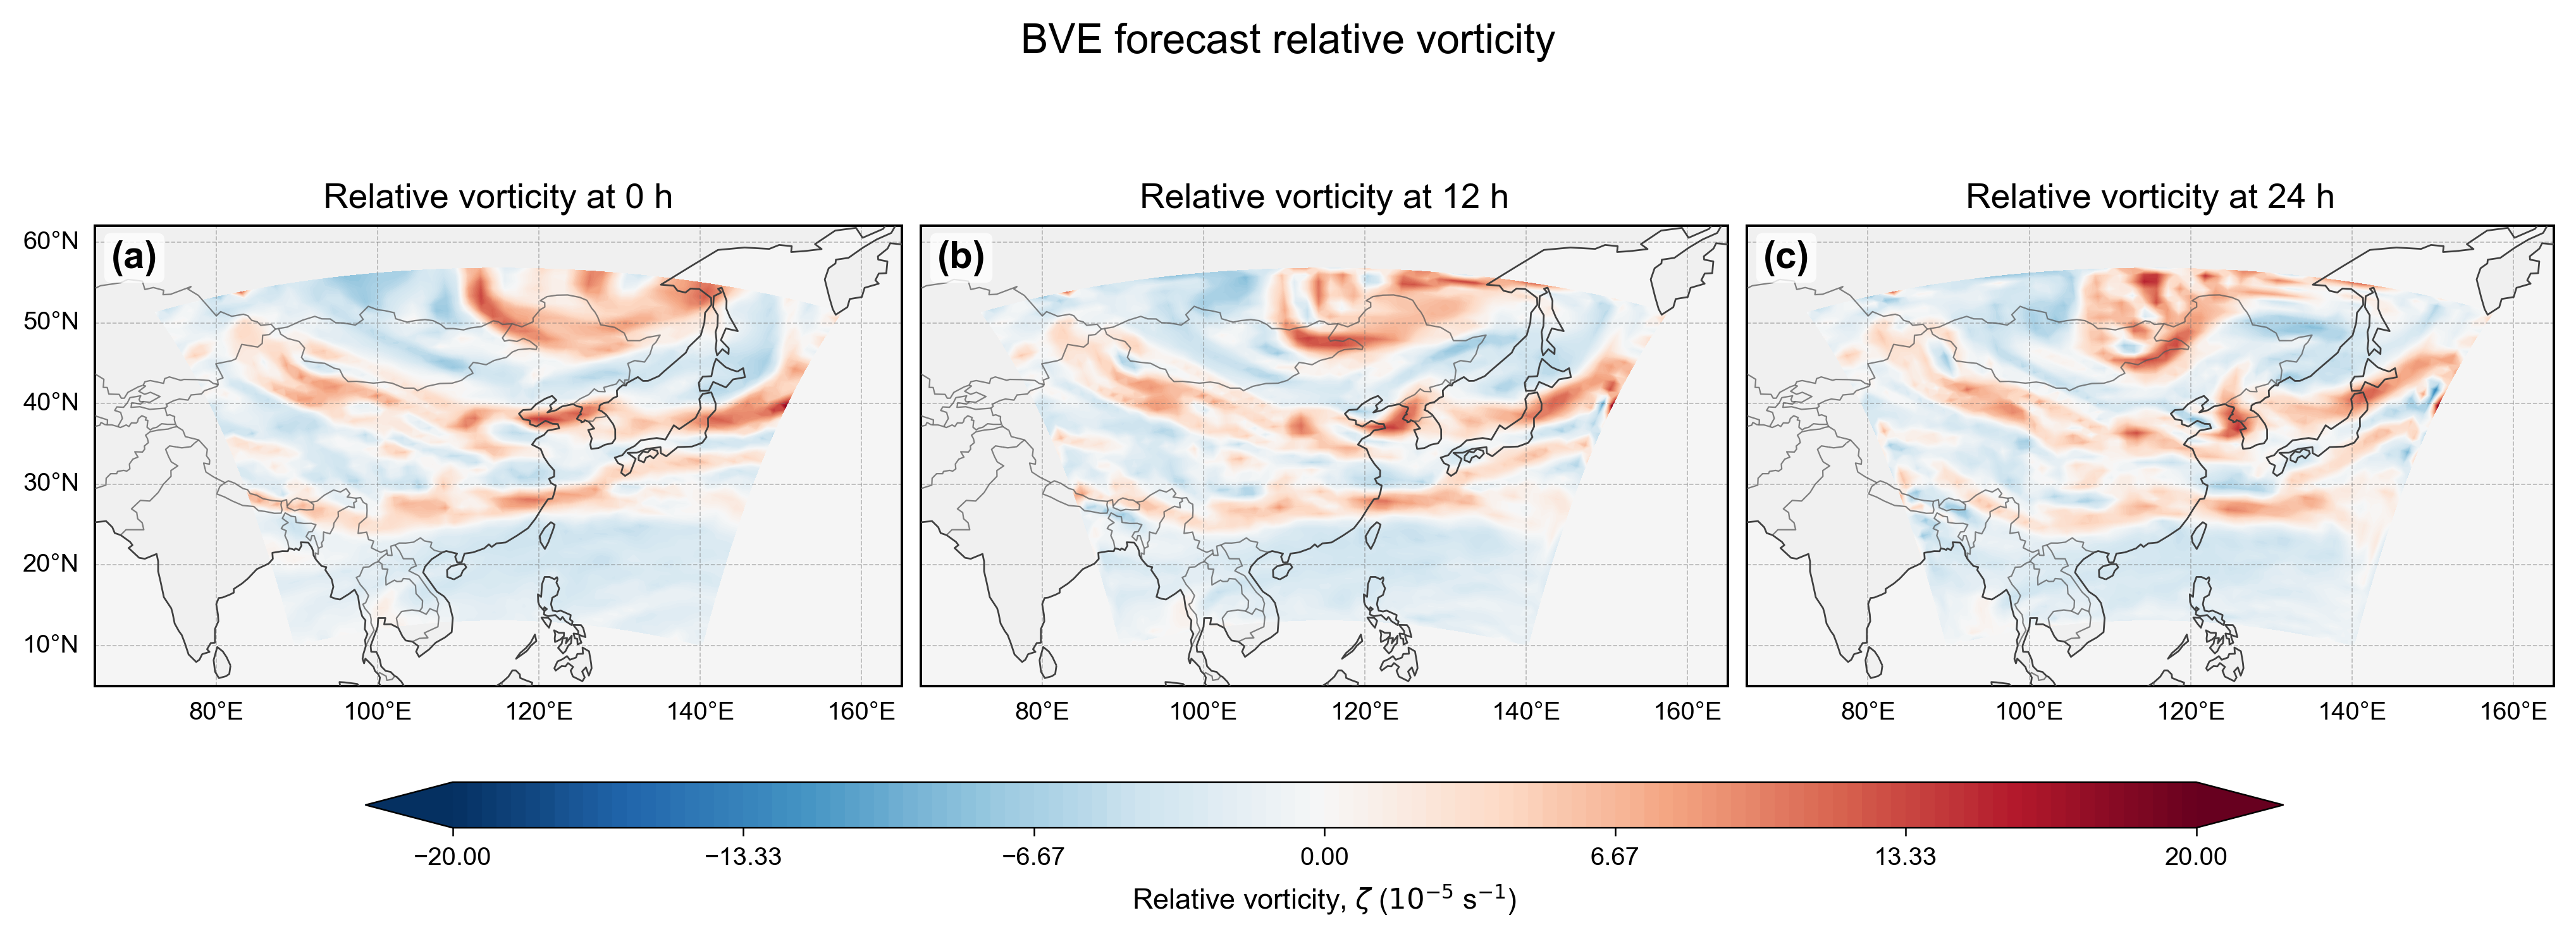

Saved vorticity figures to: ../figures/02_bve
Saved individual vorticity panels to: ../figures/02_bve/02_bve_individual_panels


In [8]:
# --- Publication-style plotting setup and Plot 1: Relative vorticity evolution ---
# This cell only changes the visualization layer: figure style, map features, colorbar,
# layout, and figure export. It does not change the BVE computation above.

%config InlineBackend.figure_format = 'retina'

import os
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# High-resolution display/export settings
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "text.antialiased": True,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# Keep the original figure directory, but make it explicit and robust.
OUTPUT_FIG_DIR = "../figures/02_bve"
INDIVIDUAL_FIG_DIR = os.path.join(OUTPUT_FIG_DIR, "02_bve_individual_panels")
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(INDIVIDUAL_FIG_DIR, exist_ok=True)

# User's IPCC continuous colorbar path for geopotential-height plotting.
# The folder name is intentionally kept as "continous" to match the actual local path.
IPCC_Z500_CMAP_PATH = "/Users/weiyingwan/Desktop/科研/绘图/color bar/IPCC/continous/temp_div.txt"

MAP_CRS = ccrs.PlateCarree()
map_extent = [65, 165, 5, 62]


def save_figure(fig, basename, out_dir=OUTPUT_FIG_DIR):
    """Save one figure as both high-resolution PNG and vector PDF."""
    png_path = os.path.join(out_dir, f"{basename}.png")
    pdf_path = os.path.join(out_dir, f"{basename}.pdf")
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    return png_path, pdf_path


def load_ipcc_continuous_cmap(cmap_path, name="ipcc_continuous", fallback="RdBu_r", n_colors=256):
    """
    Robustly load an IPCC-style continuous colormap.

    Supported line formats:
      R G B
      temp_div_5 R G B

    Notes:
      - RGB may be in 0-255 or 0-1.
      - Non-numeric columns are ignored.
      - Embedded digits in names such as "temp_div_5" are not parsed as numbers.
    """
    rgb_rows = []

    if not os.path.exists(cmap_path):
        print(f"Warning: IPCC colormap file not found: {cmap_path}. Using fallback colormap '{fallback}'.")
        return plt.get_cmap(fallback)

    with open(cmap_path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if (not line) or line.startswith("#"):
                continue

            # Allow comma- or whitespace-separated files.
            tokens = line.replace(",", " ").split()
            numeric_tokens = []
            for token in tokens:
                try:
                    numeric_tokens.append(float(token))
                except ValueError:
                    # Ignore non-numeric names such as temp_div_5.
                    pass

            if len(numeric_tokens) >= 3:
                # Use the last three numeric values so optional leading numeric indices are ignored.
                rgb_rows.append(numeric_tokens[-3:])

    if len(rgb_rows) < 2:
        print(f"Warning: could not parse enough RGB rows from {cmap_path}. Using fallback colormap '{fallback}'.")
        return plt.get_cmap(fallback)

    colors = np.asarray(rgb_rows, dtype=float)
    if np.nanmax(colors) > 1.0:
        colors = colors / 255.0
    colors = np.clip(colors, 0.0, 1.0)

    return LinearSegmentedColormap.from_list(name, colors, N=n_colors)


def add_publication_map_background(ax, left_labels=True, bottom_labels=True):
    """Add low-contrast map background, thin coastlines/borders, and subtle lat-lon gridlines."""
    ax.set_extent(map_extent, crs=MAP_CRS)

    ax.add_feature(cfeature.OCEAN, facecolor="0.96", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND,  facecolor="0.94", edgecolor="none", zorder=0)
    ax.coastlines(resolution="110m", linewidth=0.55, color="0.25", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   linewidth=0.45, edgecolor="0.35", alpha=0.75, zorder=3)

    gl = ax.gridlines(crs=MAP_CRS, draw_labels=True,
                      linewidth=0.35, color="0.45", alpha=0.45, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = left_labels
    gl.bottom_labels = bottom_labels
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.FixedLocator(np.arange(60, 181, 20))
    gl.ylocator = mticker.FixedLocator(np.arange(0, 71, 10))
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}
    return gl


def add_panel_label(ax, label):
    """Add a journal-style panel label."""
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.18",
                      facecolor="white", edgecolor="none", alpha=0.78),
            zorder=10)


def polish_colorbar(cbar, label):
    """Apply consistent colorbar styling."""
    cbar.set_label(label, fontsize=9)
    cbar.ax.tick_params(labelsize=8, width=0.5, length=2.5)
    cbar.outline.set_linewidth(0.5)


# ---- Plot 1: Relative vorticity evolution ----
vort_fields = [
    ("(a)", 0,  zeta_history[0]),
    ("(b)", 12, zeta_history[12]),
    ("(c)", 24, zeta_history[24]),
]

# Plot relative vorticity in 10^-5 s^-1 for readable scientific labeling.
vort_scale = 1.0e5
vort_abs_max = max(np.nanmax(np.abs(zeta * vort_scale)) for _, _, zeta in vort_fields)
vort_lim = max(5.0, np.ceil(vort_abs_max / 5.0) * 5.0)
vort_levels = np.linspace(-vort_lim, vort_lim, 121)
vort_ticks = np.linspace(-vort_lim, vort_lim, 7)

fig, axes = plt.subplots(
    1, 3, figsize=(11.2, 3.8), constrained_layout=True,
    subplot_kw={"projection": MAP_CRS}
)

for i, (label, hr, zeta) in enumerate(vort_fields):
    ax = axes[i]
    add_publication_map_background(ax, left_labels=(i == 0), bottom_labels=True)

    cf = ax.contourf(
        lon_grid, lat_grid, zeta * vort_scale,
        levels=vort_levels, cmap="RdBu_r", extend="both",
        transform=MAP_CRS
    )

    ax.set_title(f"Relative vorticity at {hr} h", pad=6)
    add_panel_label(ax, label)

cbar = fig.colorbar(
    cf, ax=axes.ravel().tolist(), orientation="horizontal",
    shrink=0.78, aspect=42, pad=0.08, ticks=vort_ticks
)
polish_colorbar(cbar, r"Relative vorticity, $\zeta$ ($10^{-5}$ s$^{-1}$)")

fig.suptitle("BVE forecast relative vorticity", fontsize=13, y=1.04)
save_figure(fig, "02_bve_vorticity_evolution")
plt.show()

# Save individual panels while keeping the combined figure.
for label, hr, zeta in vort_fields:
    fig_i, ax_i = plt.subplots(
        figsize=(4.4, 3.5), constrained_layout=True,
        subplot_kw={"projection": MAP_CRS}
    )
    add_publication_map_background(ax_i, left_labels=True, bottom_labels=True)
    cf_i = ax_i.contourf(
        lon_grid, lat_grid, zeta * vort_scale,
        levels=vort_levels, cmap="RdBu_r", extend="both",
        transform=MAP_CRS
    )
    ax_i.set_title(f"Relative vorticity at {hr} h", pad=6)
    add_panel_label(ax_i, label)
    cbar_i = fig_i.colorbar(
        cf_i, ax=ax_i, orientation="horizontal",
        shrink=0.82, aspect=38, pad=0.08, ticks=vort_ticks
    )
    polish_colorbar(cbar_i, r"Relative vorticity, $\zeta$ ($10^{-5}$ s$^{-1}$)")
    save_figure(fig_i, f"02_bve_vorticity_t{hr:02d}h", out_dir=INDIVIDUAL_FIG_DIR)
    plt.close(fig_i)

print(f"Saved vorticity figures to: {OUTPUT_FIG_DIR}")
print(f"Saved individual vorticity panels to: {INDIVIDUAL_FIG_DIR}")


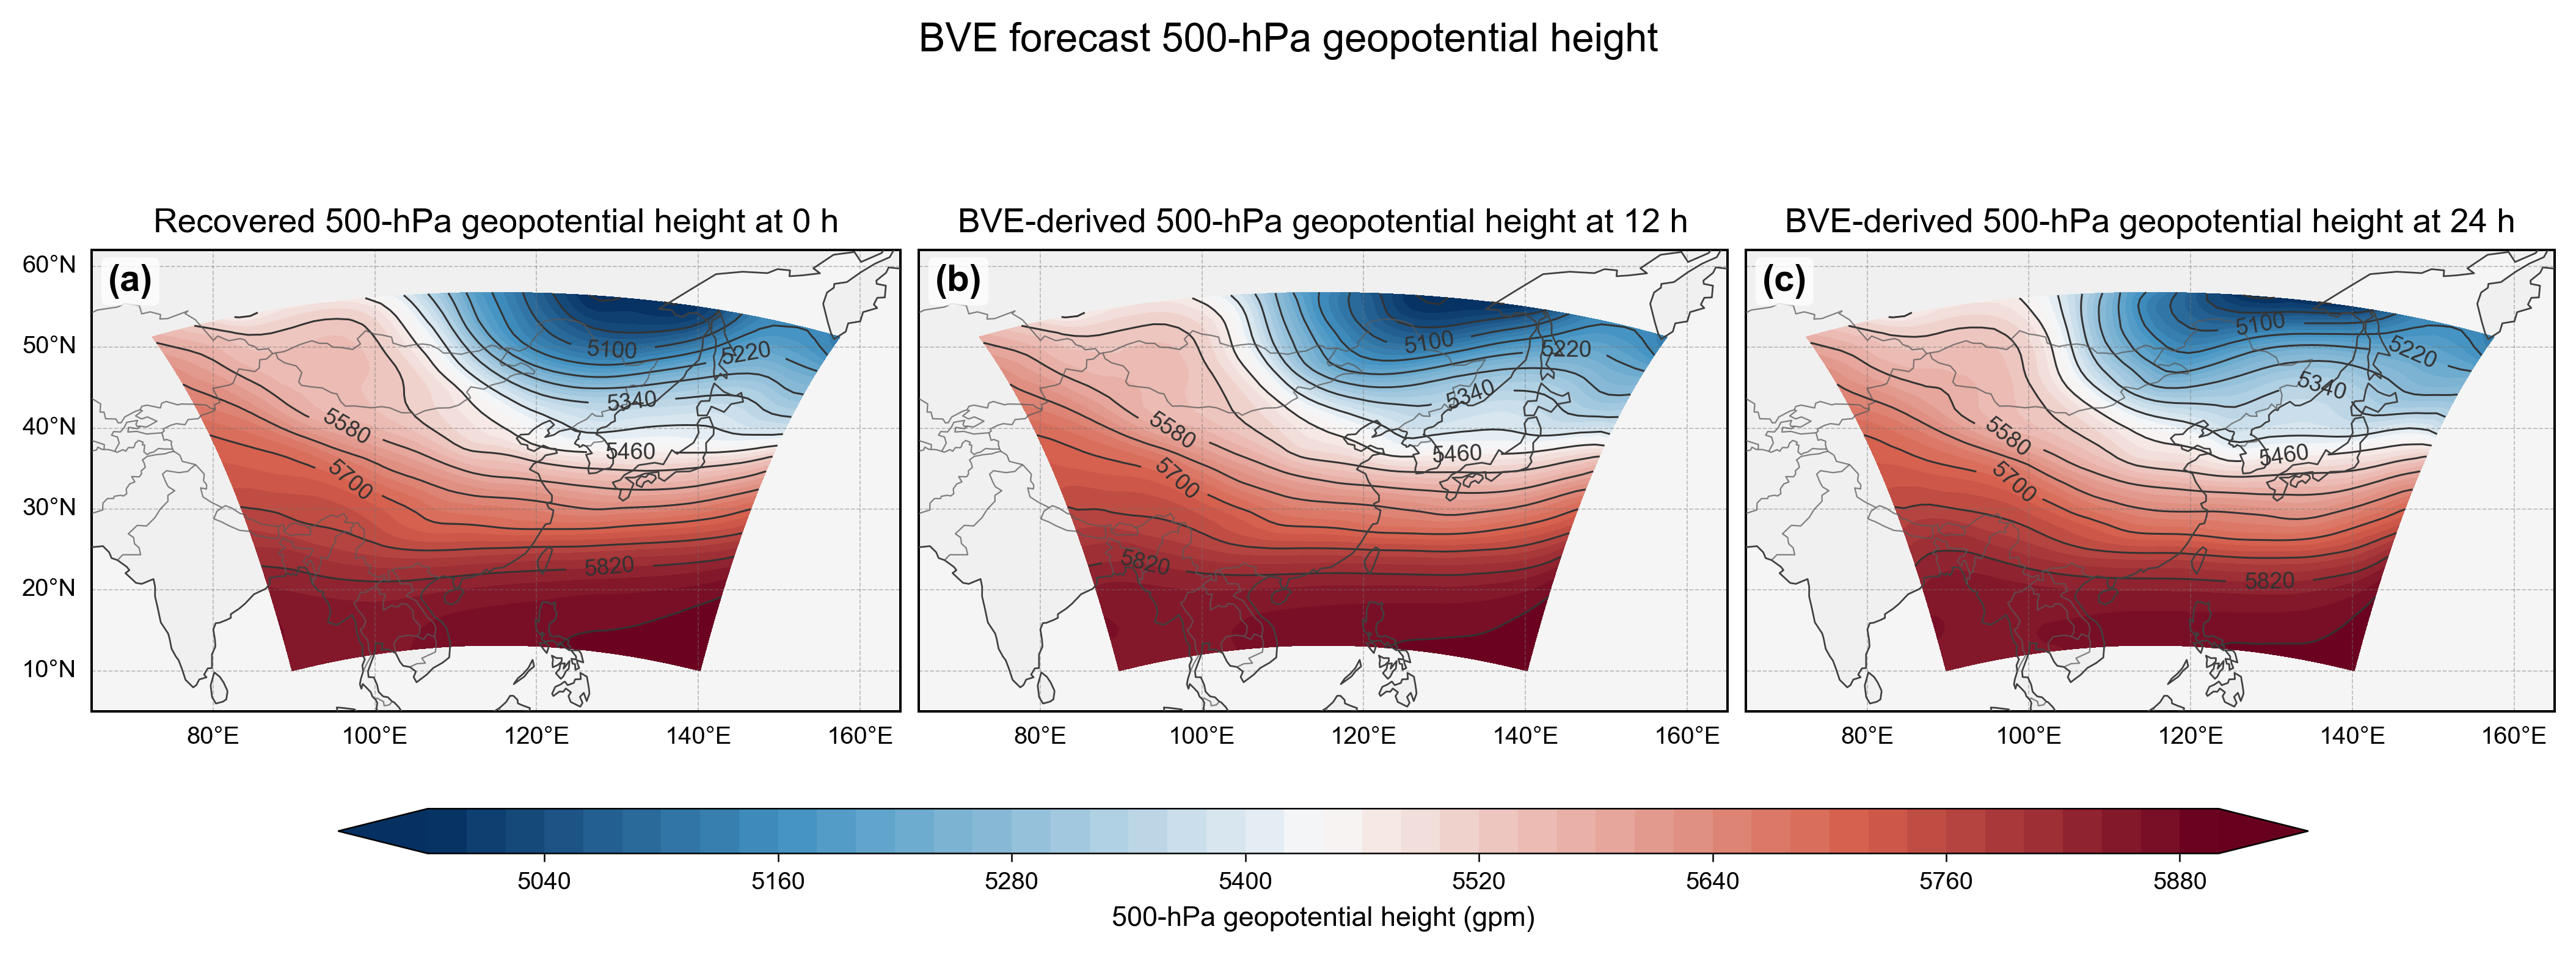

Saved Z500 figures to: ../figures/02_bve
Saved individual Z500 panels to: ../figures/02_bve/02_bve_individual_panels


In [9]:
# --- Plot 2: 500-hPa geopotential height recovered from BVE streamfunction ---
# Visualization-only changes: shared levels/colorbar, robust IPCC colormap, publication map style,
# and PNG/PDF export for both combined and individual panels.

z500_fields = [
    ("(a)", 0,  "Recovered 500-hPa geopotential height at 0 h",  z_recovered_0),
    ("(b)", 12, "BVE-derived 500-hPa geopotential height at 12 h", z_recovered_12),
    ("(c)", 24, "BVE-derived 500-hPa geopotential height at 24 h", z_recovered_24),
]

# Fixed common Z500 colorbar range for direct BVE-BPE comparison.
# This keeps the visualization scale identical across BVE and BPE figures.
z500_vmin = 4980.0
z500_vmax = 5900.0

# Dense filled levels for smooth continuous fields; sparser contours for synoptic structure.
levels_z_fill = np.arange(z500_vmin, z500_vmax + 20.0, 20.0)
levels_z_line = np.arange(np.ceil(z500_vmin / 60.0) * 60.0,
                          np.floor(z500_vmax / 60.0) * 60.0 + 60.0,
                          60.0)
z500_ticks = np.arange(np.ceil(z500_vmin / 120.0) * 120.0,
                       z500_vmax + 0.1,
                       120.0)

z500_cmap = load_ipcc_continuous_cmap(
    IPCC_Z500_CMAP_PATH,
    name="ipcc_temp_div_z500",
    fallback="RdBu_r",
    n_colors=256
)

fig, axes = plt.subplots(
    1, 3, figsize=(11.6, 4.0), constrained_layout=True,
    subplot_kw={"projection": MAP_CRS}
)

for i, (label, hr, title, field) in enumerate(z500_fields):
    ax = axes[i]
    add_publication_map_background(ax, left_labels=(i == 0), bottom_labels=True)

    cf = ax.contourf(
        lon_grid, lat_grid, field,
        levels=levels_z_fill, cmap=z500_cmap, extend="both",
        transform=MAP_CRS
    )

    cs = ax.contour(
        lon_grid, lat_grid, field,
        levels=levels_z_line, colors="0.20", linewidths=0.6,
        transform=MAP_CRS
    )
    ax.clabel(cs, cs.levels[::2], inline=True, fontsize=7.5, fmt="%d")

    ax.set_title(title, pad=6)
    add_panel_label(ax, label)

cbar = fig.colorbar(
    cf, ax=axes.ravel().tolist(), orientation="horizontal",
    shrink=0.80, aspect=44, pad=0.08, ticks=z500_ticks
)
polish_colorbar(cbar, "500-hPa geopotential height (gpm)")

fig.suptitle("BVE forecast 500-hPa geopotential height", fontsize=13, y=1.04)
save_figure(fig, "02_bve_z500_forecast")
plt.show()

# Save individual panels while keeping the combined figure.
for label, hr, title, field in z500_fields:
    fig_i, ax_i = plt.subplots(
        figsize=(4.6, 3.6), constrained_layout=True,
        subplot_kw={"projection": MAP_CRS}
    )
    add_publication_map_background(ax_i, left_labels=True, bottom_labels=True)

    cf_i = ax_i.contourf(
        lon_grid, lat_grid, field,
        levels=levels_z_fill, cmap=z500_cmap, extend="both",
        transform=MAP_CRS
    )
    cs_i = ax_i.contour(
        lon_grid, lat_grid, field,
        levels=levels_z_line, colors="0.20", linewidths=0.6,
        transform=MAP_CRS
    )
    ax_i.clabel(cs_i, cs_i.levels[::2], inline=True, fontsize=7.5, fmt="%d")

    ax_i.set_title(title, pad=6)
    add_panel_label(ax_i, label)
    cbar_i = fig_i.colorbar(
        cf_i, ax=ax_i, orientation="horizontal",
        shrink=0.82, aspect=38, pad=0.08, ticks=z500_ticks
    )
    polish_colorbar(cbar_i, "500-hPa geopotential height (gpm)")
    save_figure(fig_i, f"02_bve_z500_t{hr:02d}h", out_dir=INDIVIDUAL_FIG_DIR)
    plt.close(fig_i)

print(f"Saved Z500 figures to: {OUTPUT_FIG_DIR}")
print(f"Saved individual Z500 panels to: {INDIVIDUAL_FIG_DIR}")


## 7. Conservation Check

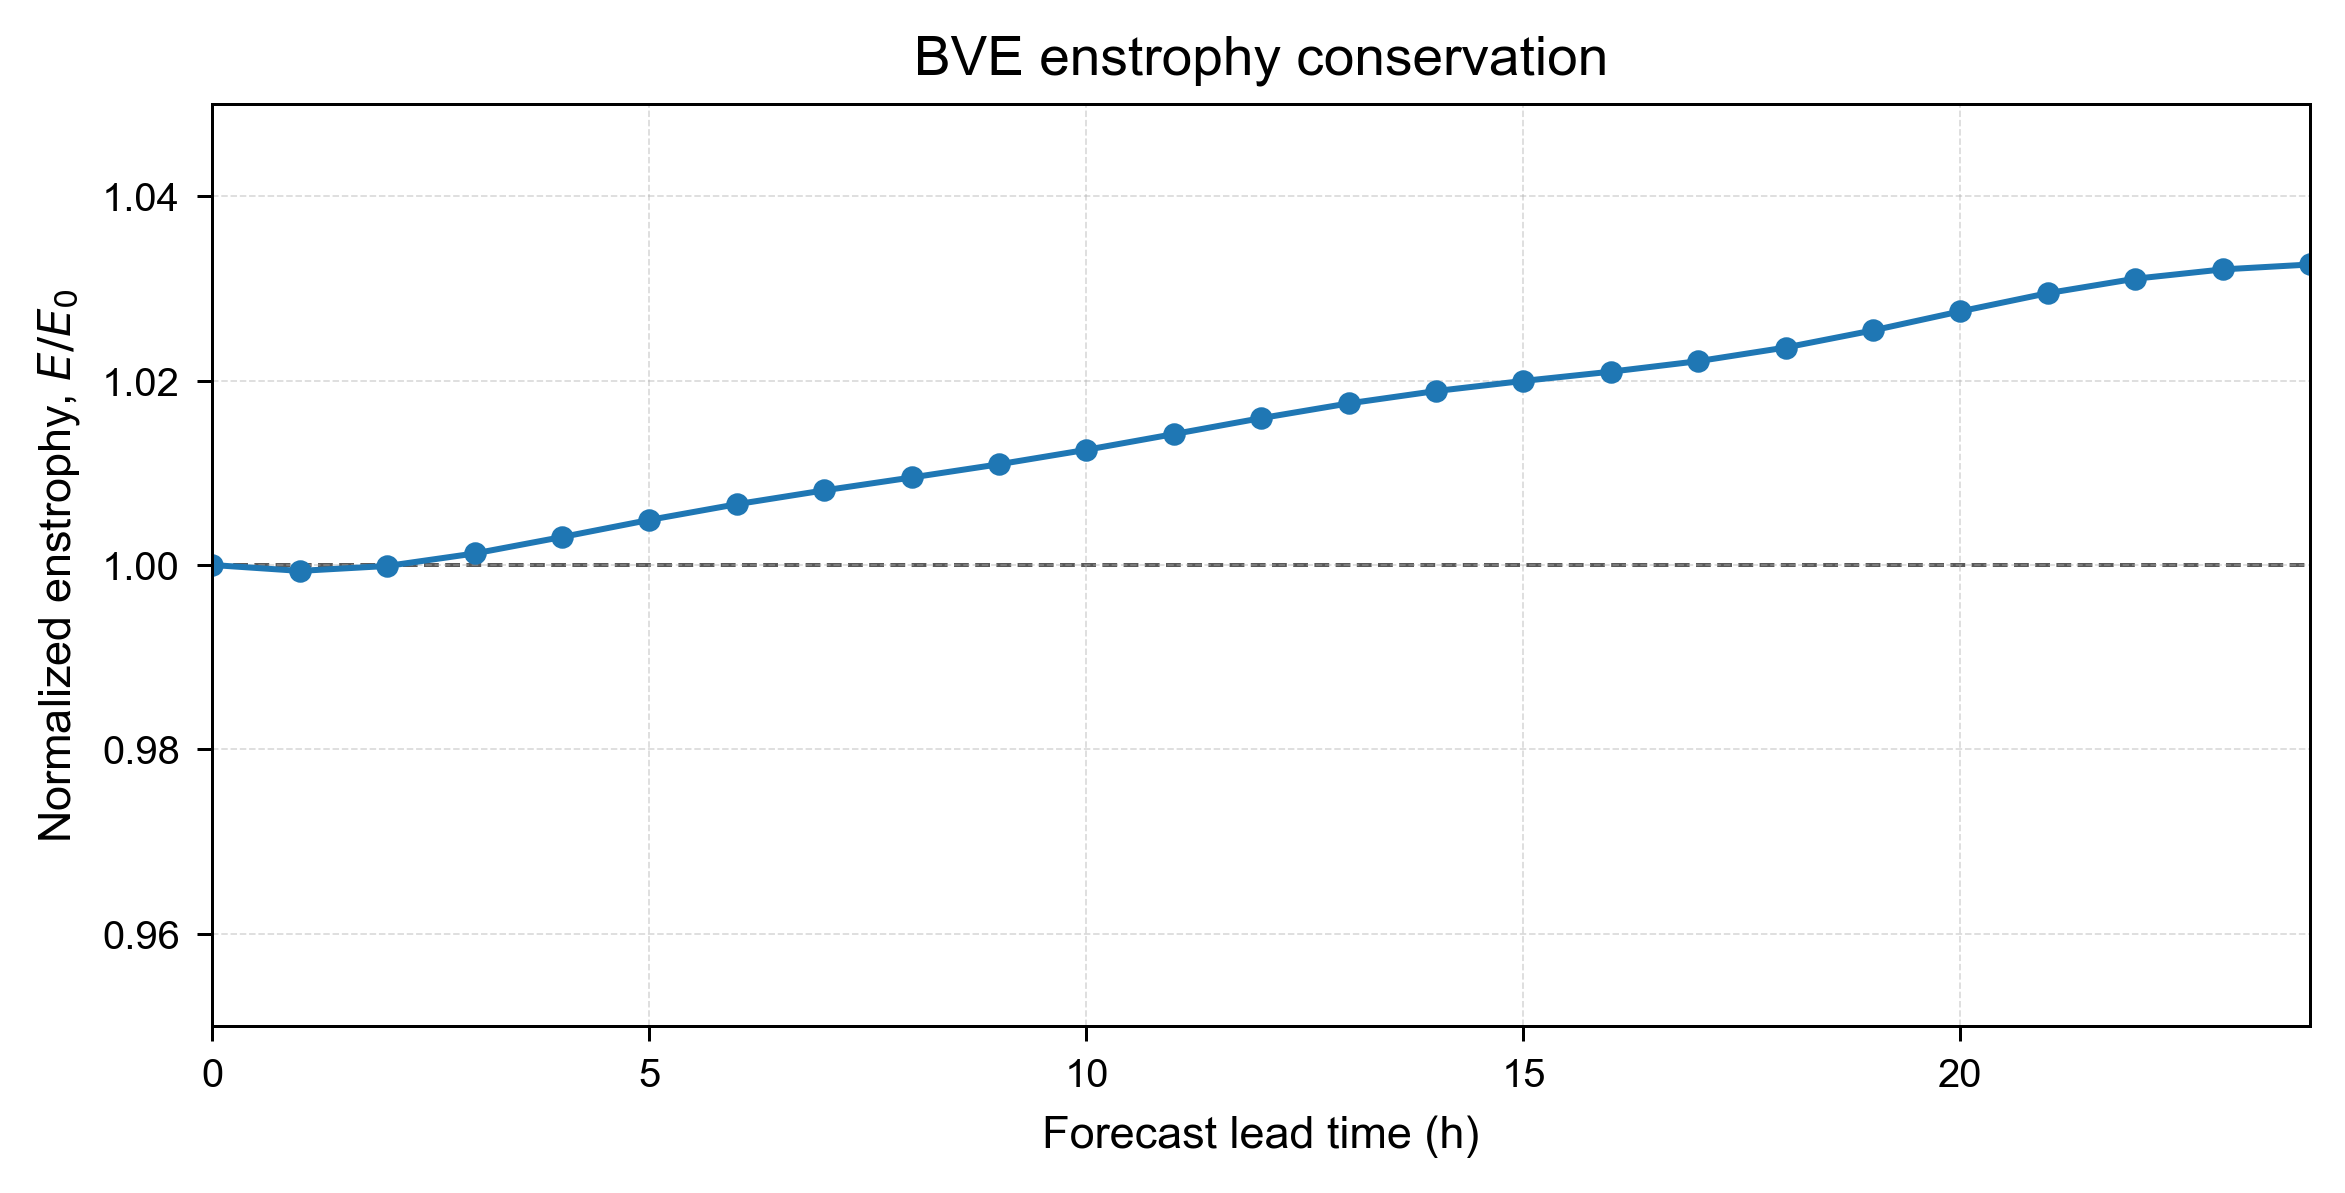

Enstrophy drift over 24 h: 3.26%
Saved enstrophy figure to: ../figures/02_bve


In [10]:
# Check enstrophy conservation (Arakawa Jacobian property)
# Computation is unchanged; only the diagnostic figure style and export settings are optimized.
enstrophy = [0.5 * np.sum(z[1:-1, 1:-1]**2) * d**2 for z in zeta_history]
enstrophy = np.array(enstrophy)

hours = np.arange(len(enstrophy))
enstrophy_ratio = enstrophy / enstrophy[0]

fig, ax = plt.subplots(figsize=(6.4, 3.2), constrained_layout=True)

ax.plot(hours, enstrophy_ratio, marker="o", markersize=3.5, linewidth=1.2)
ax.axhline(1.0, color="0.35", linewidth=0.8, linestyle="--", zorder=0)

ax.set_xlabel("Forecast lead time (h)")
ax.set_ylabel(r"Normalized enstrophy, $E/E_0$")
ax.set_title("BVE enstrophy conservation", fontsize=11, pad=6)

ax.grid(True, linewidth=0.35, alpha=0.45, linestyle="--")
ax.set_xlim(hours.min(), hours.max())
ax.set_ylim(0.95, 1.05)
ax.tick_params(labelsize=8, width=0.6, length=3)
for spine in ax.spines.values():
    spine.set_linewidth(0.6)

save_figure(fig, "02_bve_enstrophy_conservation")
plt.show()

print(f"Enstrophy drift over {n_hours} h: {(enstrophy_ratio[-1] - 1) * 100:.2f}%")
print(f"Saved enstrophy figure to: {OUTPUT_FIG_DIR}")


## 8. Save Forecast Output

In [11]:
save_path = '../data/bve_forecast.npz'
np.savez(save_path,
         zeta_history=np.array(zeta_history),
         psi_history=np.array(psi_history),
         z_recovered_0=z_recovered_0,
         z_recovered_12=z_recovered_12,
         z_recovered_24=z_recovered_24,
         dt=dt, n_steps=n_steps, n_hours=n_hours,
         alpha_ra=alpha_ra)
print(f'Saved to {save_path}')
print(f'  zeta_history: {np.array(zeta_history).shape} (hourly snapshots)')
print(f'  psi_history:  {np.array(psi_history).shape}')

Saved to ../data/bve_forecast.npz
  zeta_history: (25, 50, 60) (hourly snapshots)
  psi_history:  (25, 50, 60)
